# Manifold Learning: Desenrollando Datos con t-SNE y UMAP

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/12_manifold_learning_tsne.ipynb)

## Objetivos


- Comprender la limitación fundamental de PCA: su incapacidad para modelar relaciones no lineales.
- Introducir el concepto de *Manifold Learning* (Aprendizaje de Variedades) para "desenrollar" datos complejos.
- Comparar visual y computacionalmente **t-SNE** y **UMAP** en un problema de alta dimensionalidad.
- **Criterio de Ingeniería:** Entender por qué estas herramientas son vitales para el Análisis Exploratorio (EDA) y la depuración de modelos, pero rara vez se utilizan en *Pipelines* de producción en tiempo real.



## Prerrequisitos


- Entendimiento de la reducción de dimensionalidad lineal.
- Haber completado: [Reducción de Dimensionalidad: PCA y Reconstrucción](11_pca_y_reconstruccion.ipynb).

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

    # UMAP no viene preinstalado en Colab, lo instalamos
    subprocess.run(["pip", "install", "umap-learn"], check=True)
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

## Introducción Teórica


En el notebook anterior vimos que PCA es excelente para comprimir información. Sin embargo, PCA tiene un punto ciego masivo: **asume que el mundo es plano (lineal)**.

Imaginemos que nuestros datos tienen la forma de un papel arrugado o un espiral tridimensional (el clásico problema del *Swiss Roll*). Si se usa PCA, el algoritmo intentará aplastar ese espiral proyectándolo sobre una línea recta. El resultado será un desastre donde puntos que estaban muy lejos en el espiral terminarán superpuestos.

Necesitamos algoritmos que no "aplasten" los datos, sino que los **desenrollen**. A esta familia de algoritmos se le conoce como **Manifold Learning**.

### 1. t-SNE (t-Distributed Stochastic Neighbor Embedding)


Desarrollado en 2008, revolucionó la visualización de datos. Su filosofía es simple:
- Mide las distancias entre todos los puntos en el espacio original de alta dimensión.
- Crea un espacio 2D vacío.
- Mueve los puntos en el espacio 2D intentando que **los puntos que estaban cerca en alta dimensión sigan estando cerca en 2D**.
- **El problema:** A t-SNE solo le importa la estructura *local*. Agrupa muy bien las cosas similares, pero la distancia entre dos grupos diferentes en el gráfico final no significa absolutamente nada (estructura *global* destruida). Además, es computacionalmente costoso (lento).

### 2. UMAP (Uniform Manifold Approximation and Projection)


Desarrollado en 2018, es el estándar moderno. Basado en topología matemática profunda, UMAP logra lo mismo que t-SNE pero con dos ventajas masivas para la ingeniería:
1. **Es drásticamente más rápido** (escala muy bien con millones de filas).
2. **Preserva la estructura global.** Si el Grupo A está más cerca del Grupo B que del Grupo C en el gráfico 2D de UMAP, es porque realmente se parecen más en la alta dimensión.

Va un pequeño ejemplo visual:

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


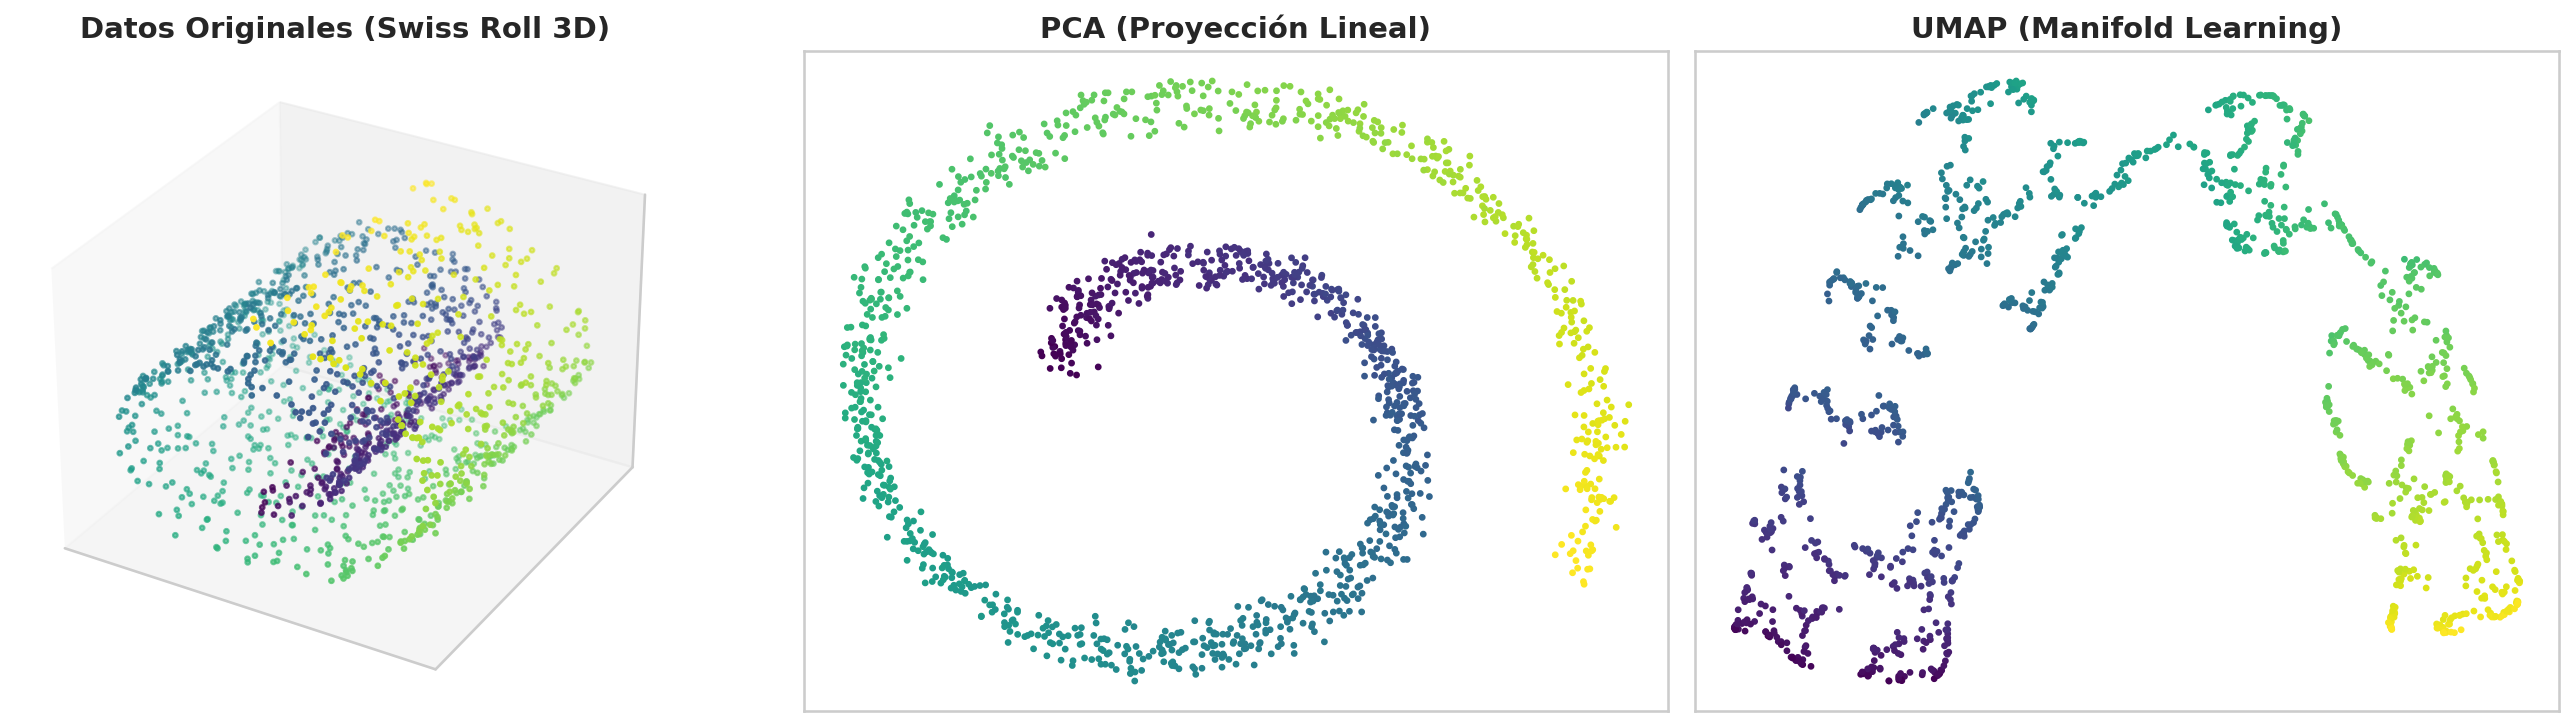

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Intentamos importar UMAP (opcional)
try:
    import umap
    use_umap = True
except ImportError:
    use_umap = False

# === 1. Generar Swiss Roll ===
X, t = make_swiss_roll(n_samples=1500, noise=0.3)
colors = t  # gradiente continuo

# === 2. PCA (fallo lineal) ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# === 3. Manifold Learning (UMAP o t-SNE) ===
if use_umap:
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_manifold = reducer.fit_transform(X)
    method_name = "UMAP"
else:
    reducer = TSNE(n_components=2, random_state=42, perplexity=30)
    X_manifold = reducer.fit_transform(X)
    method_name = "t-SNE"

# === 4. Plot ===
fig = plt.figure(figsize=(18, 5))

# --- Izquierda: 3D Swiss Roll ---
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=colors, cmap='viridis', s=5)
ax1.set_title("Datos Originales (Swiss Roll 3D)")
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_zticks([])

# --- Centro: PCA ---
ax2 = fig.add_subplot(132)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, cmap='viridis', s=5)
ax2.set_title("PCA (Proyección Lineal)")
ax2.set_xticks([])
ax2.set_yticks([])

# --- Derecha: Manifold Learning ---
ax3 = fig.add_subplot(133)
ax3.scatter(X_manifold[:, 0], X_manifold[:, 1], c=colors, cmap='viridis', s=5)
ax3.set_title(f"{method_name} (Manifold Learning)")
ax3.set_xticks([])
ax3.set_yticks([])

plt.tight_layout()
plt.show()

Ver como "los grupos" densos permanecen juntos en el espacio 2D (para Manifold Learning), para PCA, simplemente se superponen.

## Desarrollo e Implementación


Para demostrar el poder de estas herramientas, no usamos datos tabulares simples. Usaremos el **Digits Dataset**, que contiene imágenes de 8x8 píxeles de números escritos a mano.

Cada píxel es una columna. Por lo tanto, **nuestros datos viven en un espacio de 64 dimensiones**. Nuestro objetivo es reducirlos a 2 dimensiones para ver si los algoritmos logran agrupar los números iguales sin que nosotros les digamos qué número es cuál (Aprendizaje No Supervisado).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# 1. Carga de datos (Imágenes 8x8 = 64 dimensiones)
digits = load_digits()
X = digits.data
y = digits.target # Solo usamos 'y' para colorear el gráfico final, los algoritmos NO lo verán.

print(f"Dimensiones originales: {X.shape} (1797 imágenes, 64 píxeles cada una)")

# 2. Estandarización (Vital para algoritmos basados en distancias como t-SNE y UMAP)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Dimensiones originales: (1797, 64) (1797 imágenes, 64 píxeles cada una)


### La Gran Comparativa: PCA vs t-SNE vs UMAP



Vamos a ejecutar los tres algoritmos sobre las mismas 1797 imágenes y medimos cuánto tardan.

In [8]:
# --- 1. PCA (Baseline Lineal) ---
start_time = time.time()
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
time_pca = time.time() - start_time

# --- 2. t-SNE (Manifold Clásico) ---
# Nota: t-SNE es estocástico (aleatorio), fijamos la semilla para reproducibilidad
start_time = time.time()
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_scaled)
time_tsne = time.time() - start_time

# --- 3. UMAP (Manifold Moderno) ---
start_time = time.time()
umap_model = umap.UMAP(n_components=2, random_state=42, n_jobs=-1)
X_umap = umap_model.fit_transform(X_scaled)
time_umap = time.time() - start_time

print(f"Tiempos de ejecución:")
print(f"PCA:    {time_pca:.4f} segundos")
print(f"UMAP:   {time_umap:.4f} segundos")
print(f"t-SNE:  {time_tsne:.4f} segundos")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tiempos de ejecución:
PCA:    0.0341 segundos
UMAP:   9.5255 segundos
t-SNE:  28.0009 segundos


*Nota de Ingeniería:* En este dataset pequeño (~1800 filas), UMAP y t-SNE tardan un par de segundos. Pero si se tuvieran 500000 filas, t-SNE podría tardar horas, mientras que UMAP terminaría en minutos.

### Visualizando el Espacio Latente (Embeddings)


Ahora, graficamos los resultados. Coloreamos los puntos según el número real que representan (del 0 al 9) para ver si los algoritmos lograron agruparlos correctamente en 2D.

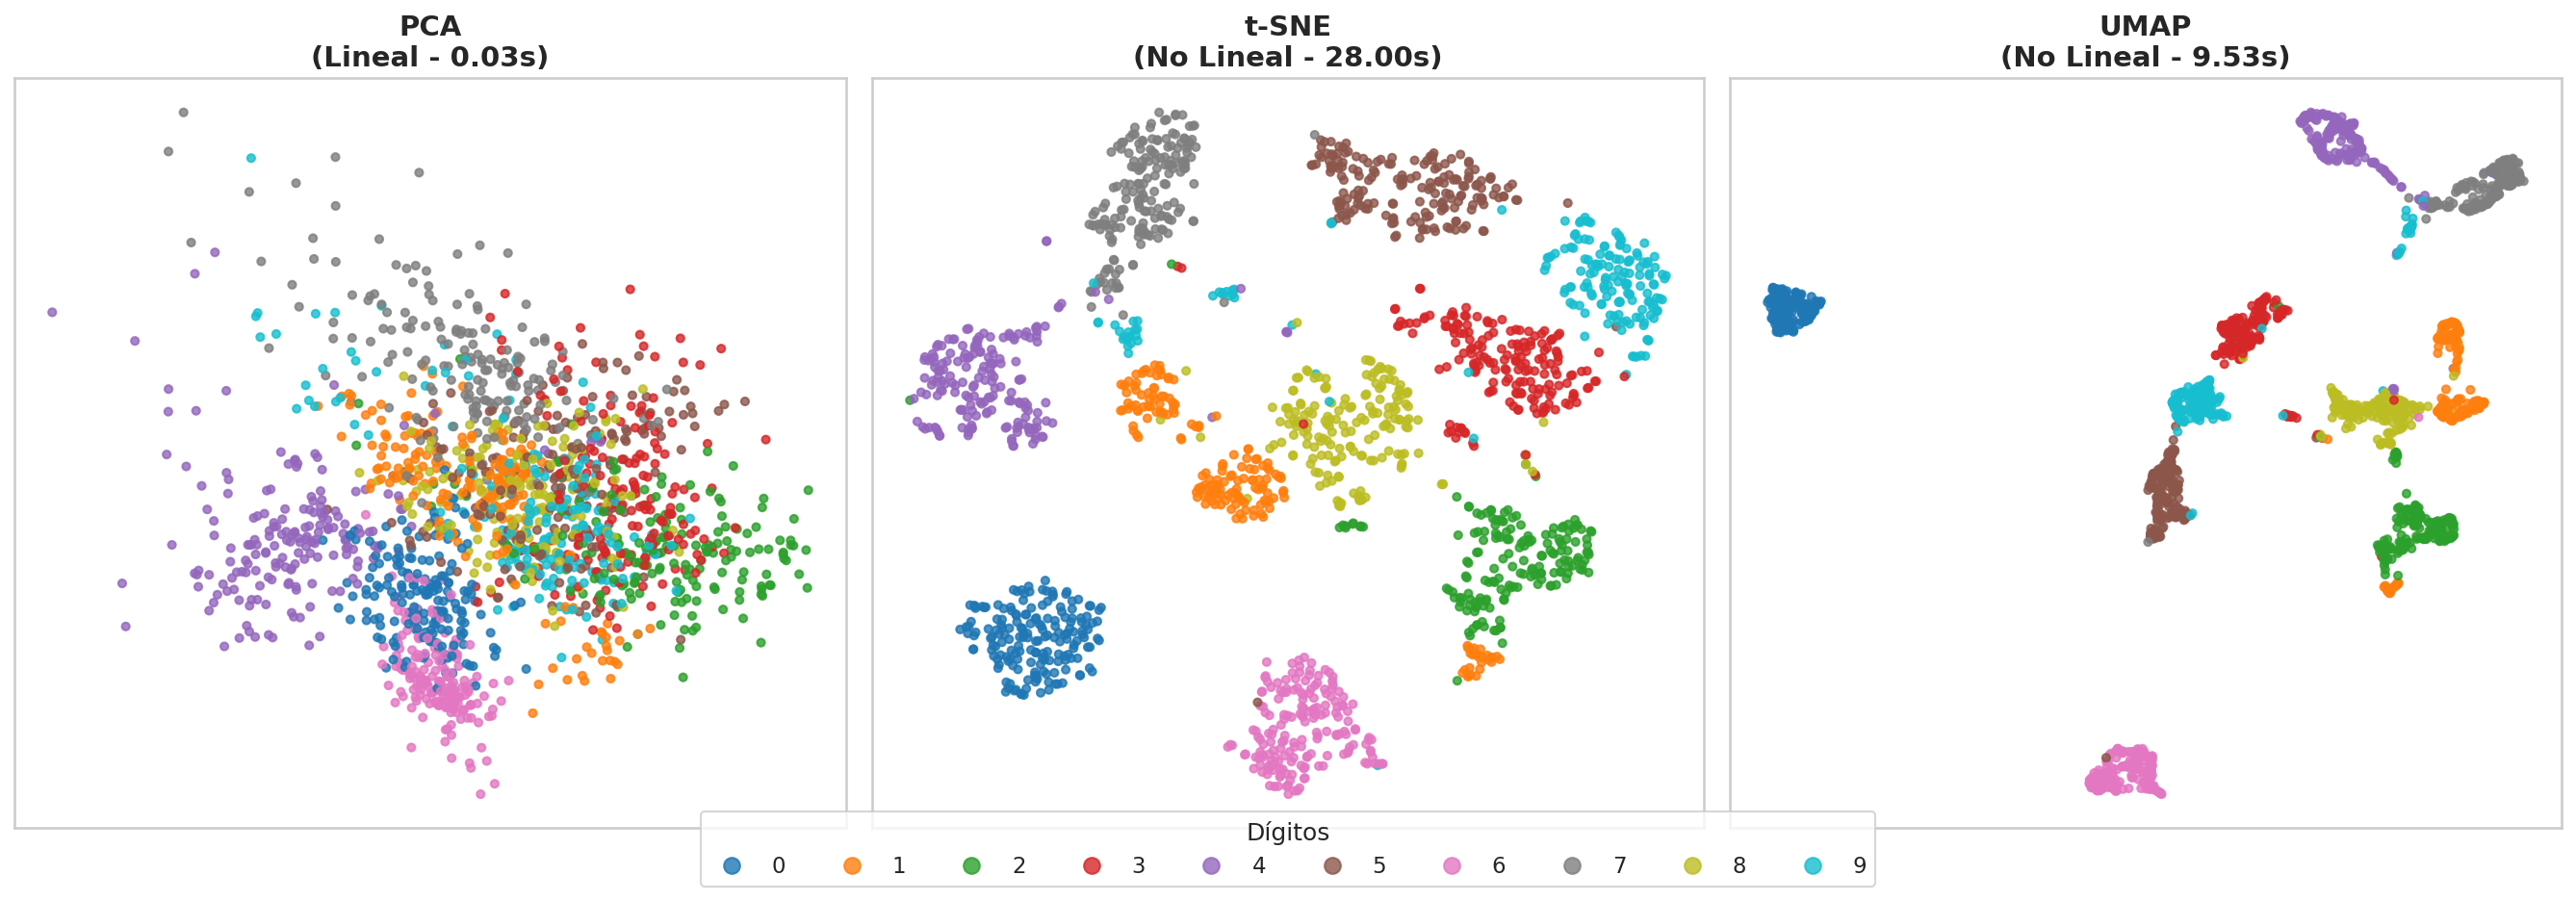

In [9]:
# Función auxiliar para graficar
def plot_embedding(X_emb, y, title, ax):
    scatter = ax.scatter(X_emb[:, 0], X_emb[:, 1], c=y, cmap='tab10', s=15, alpha=0.8)
    ax.set_title(title, fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
    return scatter

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_embedding(X_pca, y, f"PCA\n(Lineal - {time_pca:.2f}s)", axes[0])
plot_embedding(X_tsne, y, f"t-SNE\n(No Lineal - {time_tsne:.2f}s)", axes[1])
scatter = plot_embedding(X_umap, y, f"UMAP\n(No Lineal - {time_umap:.2f}s)", axes[2])

# Añadimos una leyenda global
legend = fig.legend(*scatter.legend_elements(), title="Dígitos", loc="lower center", ncol=10, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

## Resultados y Discusión


Analizar los tres gráficos con ojo crítico:

1. **PCA (Izquierda):** Es un desastre. Al intentar aplastar 64 dimensiones en 2 usando líneas rectas, los números se mezclan en una gran mancha central. Es imposible separar un 3 de un 9 o un 5.
2. **t-SNE (Centro):** ¡Magia! Sin saber qué número era cuál, t-SNE logró agrupar las imágenes idénticas en "islas" perfectamente separadas. Sin embargo, observa la distancia entre las islas: están dispersas casi al azar.
3. **UMAP (Derecha):** Logra una separación equivalente a la de t-SNE, pero **preserva la estructura global**. Observar cómo el grupo de los `1` (naranja) está muy cerca del grupo de los `7` (gris), porque visualmente un 1 y un 7 se parecen mucho. Los `4` y los `9` también suelen estar cerca. UMAP entendió la semántica de los datos.

---

## ⚠️ Alerta de Ingeniería: ¿Por qué no usar esto en Producción?


Si UMAP y t-SNE son tan increíbles separando datos, ¿por qué no los ponemos en un `Pipeline` antes de un Random Forest para mejorar el *Accuracy*?

**1. El Problema Transductivo (t-SNE):**
La implementación estándar de t-SNE en Scikit-Learn **no tiene el método `.transform()`**. Solo tiene `.fit_transform()`. Esto significa que no puede aprender una regla matemática y aplicarla a un dato nuevo. Si llega un nuevo usuario a la API en producción, t-SNE tendría que recalcular las distancias de ese usuario contra *toda* la base de datos histórica para ubicarlo en el mapa 2D. Esto es inviable en tiempo real.

**2. El Costo Computacional (UMAP):**
UMAP *sí* posee un método `.transform()`, lo que permite proyectar datos nuevos. Sin embargo, la matemática topológica subyacente es pesada. Añadir UMAP como paso de preprocesamiento en una API de alta concurrencia añadirá una latencia inaceptable (milisegundos vs microsegundos de PCA).

### Entonces, ¿Para qué sirven en la vida real?



En la industria, UMAP y t-SNE son herramientas de **Análisis y Depuración**, no de preprocesamiento en tiempo real. Sus casos de uso estrella son:

1. **Descubrimiento de Clusters (EDA Avanzado):** Antes de aplicar algoritmos de Clustering (como K-Means), se proyectan los datos con UMAP (visualización pura, bajamos de N dimensiones a 2 o 3). Si en UMAP se ve una sola mancha gigante, es probable que no existan clusters naturales en los datos. Si se ven islas claras (como en nuestro gráfico), el clustering será un éxito.
2. **Depuración de Redes Neuronales (Deep Learning):** Las redes neuronales son cajas negras. Una técnica común es extraer la última capa oculta de la red (que puede tener 512 dimensiones) y graficarla con UMAP. Si la red ha aprendido correctamente, se verán las clases perfectamente separadas. Si se ve una mezcla, la red no está aprendiendo, sin importar lo que diga la métrica de *Loss*.
3. **Análisis de Embeddings (NLP):** Para visualizar cómo un modelo de lenguaje (como Word2Vec o BERT) agrupa palabras o documentos semánticamente similares.

## Conexiones y Próximos Pasos



Hemos visto cómo UMAP y t-SNE revelan agrupaciones ocultas en los datos de forma visual. Pero en ingeniería, no nos basta con "ver" los grupos; necesitamos que un algoritmo asigne una etiqueta matemática a cada punto (Ej. "Tú perteneces al Cluster 0").

- ➡️ **Siguiente:** En el notebook [K-Means y sus Limitaciones](13_kmeans_y_sus_limitaciones.ipynb), entramos de lleno en el mundo del **Clustering**. Aprendemos a agrupar datos automáticamente y, más importante aún, descubriremos por qué el algoritmo más famoso del mundo (K-Means) fracasa  si los datos no tienen forma de esfera.
- 🔄 **Relacionado:** Si te interesa cómo una Red Neuronal puede aprender a reducir dimensionalidad de forma no lineal *y* paramétrica (apta para producción), investiga sobre los **Autoencoders**. Los abordamos en el capítulo de *deep learning* igualmente...



## Referencias


1. McInnes, L., Healy, J., & Melville, J. (2018). *UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction*. arXiv preprint arXiv:1802.03426.
2. Wattenberg, et al., (2016). *How to Use t-SNE Effectively*. Distill. [Enlace interactivo](https://distill.pub/2016/misread-tsne/)

---


## Entorno de Ejecución


In [11]:
from utils.environment import environment_table
environment_table(include_all=True)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
Cython,3.0.12
IPython,7.34.0
OpenSSL,24.2.1
PIL,11.3.0
anywidget,0.9.21
argparse,1.1
astunparse,1.6.3
attr,26.1.0
